In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("./data/air_data/info batch date and time.xlsx").dropna(how = "all")
df.sort_values(by = "batch")
df["start_date"] = df["Date online extraction"].apply(lambda x: pd.to_datetime(x.split()[0], dayfirst = True))
df["end_date"] = df["Date online extraction"].apply(lambda x: pd.to_datetime(x.split()[-1], dayfirst = True))
df["date_diff"] = df["end_date"] - df["start_date"]
df.drop("Date online extraction", axis = 1, inplace = True)
df.to_csv("./processed/batch_info.csv", index = None)
batch_info = df.copy()

In [4]:
batch_info

,STR,batch,start_date,end_date,date_diff
0,DB440,FA004,2025-11-17,2025-12-03,16 days
1,DB450,FA005,2025-12-01,2025-12-16,15 days
2,DB460,FA006,2025-12-23,2026-01-07,15 days
3,DB440,FA007,2026-01-06,2026-01-21,15 days
4,DB450,FA001,2025-04-01,2025-04-16,15 days
5,DB460,FA008,2026-01-20,2026-02-04,15 days
6,DB440,FA009,2026-01-30,2026-02-14,15 days
7,DB450,FA002,2025-04-29,2025-05-14,15 days
8,DB460,FA010,2026-02-09,2026-02-24,15 days
9,DB440,FA011,2026-02-19,2026-03-06,15 days


In [8]:
batch_start = {}
batch_end   = {}
for row_idx, row in batch_info.iterrows():
    batch_start[row["batch"]] = pd.to_datetime(row["start_date"])
    batch_end[row["batch"]] = pd.to_datetime(row["end_date"])
mapping = {val:f"FA{str(i + 1).zfill(3)}" for i, val in enumerate(sorted(oxygen_df["start"].unique()))}
len(mapping)

11

In [9]:
oxygen_df

,db,start,end,tag,point,timestamp,value
0,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:00:00.0000000,-0.018750
1,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:48.5278167,-0.018750
2,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:49.5278167,-0.021875
3,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:54.5748138,-0.018750
4,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:10:39.6615600,-0.018750
...,...,...,...,...,...,...,...
982492,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:13:54.1516723,-0.025000
982493,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:25.2472839,-0.021875
982494,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:43.3020172,-0.021875
982495,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:44.3020172,-0.025000


In [10]:
mapping

{Timestamp('2025-04-01 00:00:00'): 'FA001',
 Timestamp('2025-04-19 00:00:00'): 'FA002',
 Timestamp('2025-05-20 00:00:00'): 'FA003',
 Timestamp('2025-11-17 00:00:00'): 'FA004',
 Timestamp('2025-12-01 00:00:00'): 'FA005',
 Timestamp('2025-12-23 00:00:00'): 'FA006',
 Timestamp('2026-01-06 00:00:00'): 'FA007',
 Timestamp('2026-01-20 00:00:00'): 'FA008',
 Timestamp('2026-01-30 00:00:00'): 'FA009',
 Timestamp('2026-02-09 00:00:00'): 'FA010',
 Timestamp('2026-02-19 00:00:00'): 'FA011'}

In [11]:
oxygen_df = pd.read_csv("./data/air_data_csv/FI598-oxygen.csv")
oxygen_df["start"] = pd.to_datetime(oxygen_df["start"])
oxygen_df.insert(0, "Batch", oxygen_df["start"].apply(lambda x: mapping[x]))
oxygen_df

,Batch,db,start,end,tag,point,timestamp,value
0,FA004,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:00:00.0000000,-0.018750
1,FA004,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:48.5278167,-0.018750
2,FA004,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:49.5278167,-0.021875
3,FA004,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:09:54.5748138,-0.018750
4,FA004,DB0440,2025-11-17,12/3/2025 23:59,FI598_value,DB0440_FI598_value,2025-11-17 00:10:39.6615600,-0.018750
...,...,...,...,...,...,...,...,...
982492,FA010,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:13:54.1516723,-0.025000
982493,FA010,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:25.2472839,-0.021875
982494,FA010,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:43.3020172,-0.021875
982495,FA010,DB0460,2026-02-09,2/24/2026 23:59,FI598_value,DB0460_FI598_value,2026-02-24 16:14:44.3020172,-0.025000


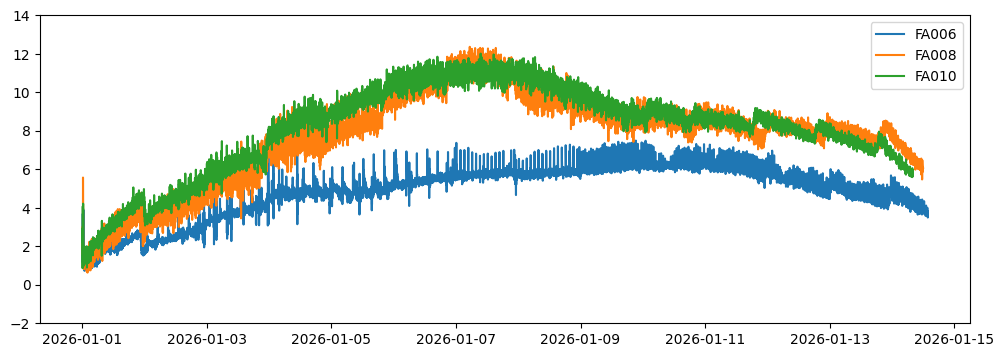

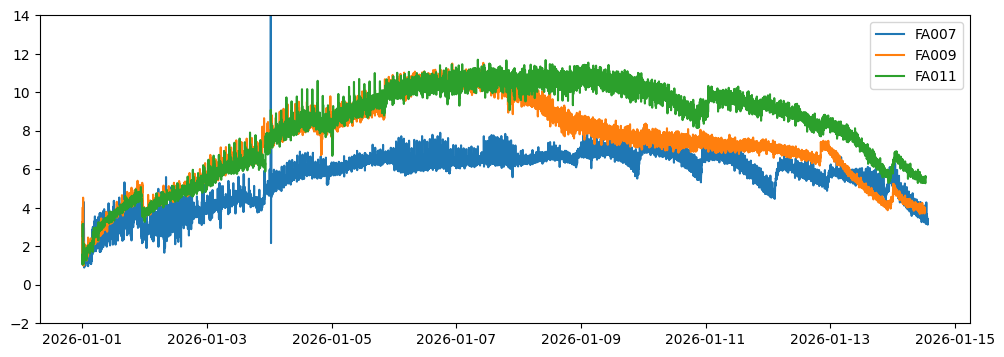

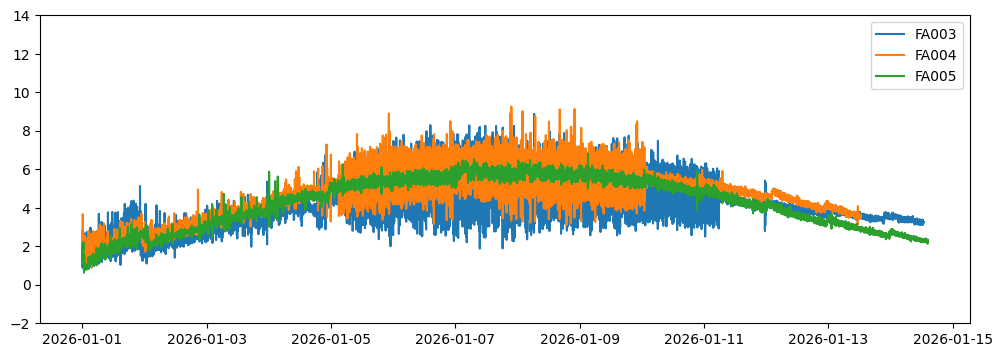

In [20]:
df_analysis = oxygen_df

plt.figure(figsize = (12, 4))
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"].rolling(15).mean(), label = batch)
plt.ylim(-2, 14)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"].rolling(15).mean(), label = batch)
plt.ylim(-2, 14)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA003", "FA004", "FA005"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"].rolling(15).mean(), label = batch)
plt.ylim(-2, 14)
plt.legend()

In [14]:
sub_df["value"].rolling(14).mean()

359078         NaN
359079         NaN
359080         NaN
359081         NaN
359082         NaN
            ...   
445073    2.175000
445074    2.193527
445075    2.213616
445076    2.237054
445077    2.264955
Name: value, Length: 85940, dtype: float64

In [63]:
temp_df = pd.read_csv("./data/air_data_csv/QI146-DO.csv")
temp_df["start"] = pd.to_datetime(temp_df["start"])
temp_df.insert(0, "Batch", temp_df["start"].apply(lambda x: mapping[x]))
temp_df

,Batch,db,start,end,tag,point,timestamp,value
0,FA004,DB0440,2025-11-17,12/3/2025 23:59,QI146_value,DB0440_QI146_value,2025-11-17 00:00:00.0000000,107.354675
1,FA004,DB0440,2025-11-17,12/3/2025 23:59,QI146_value,DB0440_QI146_value,2025-11-17 12:07:31.9758148,107.354675
2,FA004,DB0440,2025-11-17,12/3/2025 23:59,QI146_value,DB0440_QI146_value,2025-11-17 12:07:32.9758148,0.000000
3,FA004,DB0440,2025-11-17,12/3/2025 23:59,QI146_value,DB0440_QI146_value,2025-11-17 12:07:47.0226287,84.129997
4,FA004,DB0440,2025-11-17,12/3/2025 23:59,QI146_value,DB0440_QI146_value,2025-11-17 12:07:58.9025726,84.129997
...,...,...,...,...,...,...,...,...
875771,FA010,DB0460,2026-02-09,2/24/2026 23:59,QI146_value,DB0460_QI146_value,2026-02-23 11:50:24.8265075,89.070297
875772,FA010,DB0460,2026-02-09,2/24/2026 23:59,QI146_value,DB0460_QI146_value,2026-02-23 11:50:37.9853973,88.503403
875773,FA010,DB0460,2026-02-09,2/24/2026 23:59,QI146_value,DB0460_QI146_value,2026-02-23 11:51:02.0248565,88.412704
875774,FA010,DB0460,2026-02-09,2/24/2026 23:59,QI146_value,DB0460_QI146_value,2026-02-23 11:51:14.0050659,88.412704


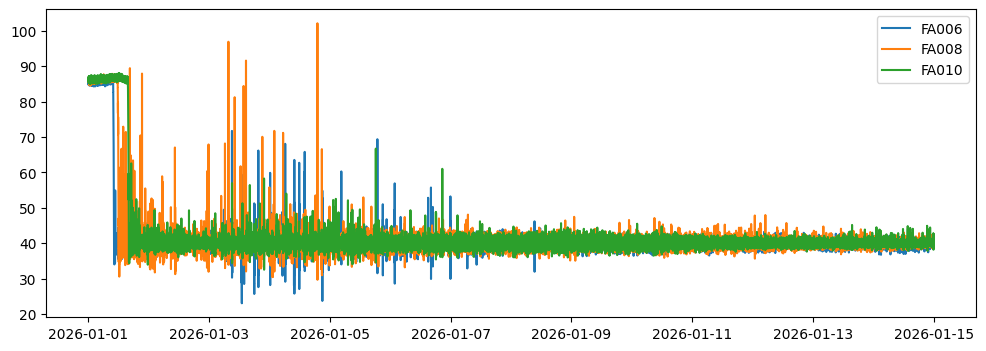

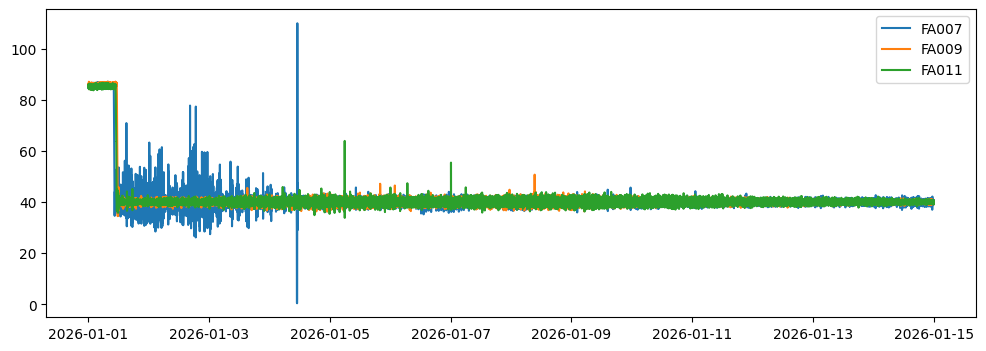

In [64]:
df_analysis = temp_df

plt.figure(figsize = (12, 4))
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    # sub_df = sub_df[sub_df["timestamp"] < pd.to_datetime("01-08-2026 00:00:00")]
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    # sub_df = sub_df[sub_df["timestamp"] < pd.to_datetime("01-08-2026 00:00:00")]
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

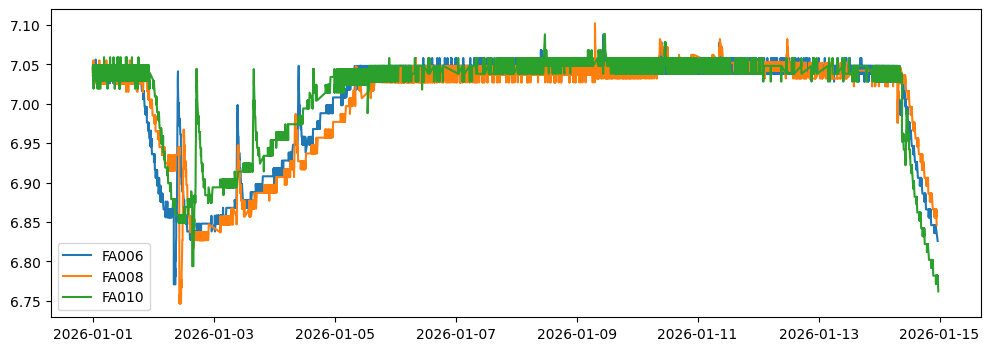

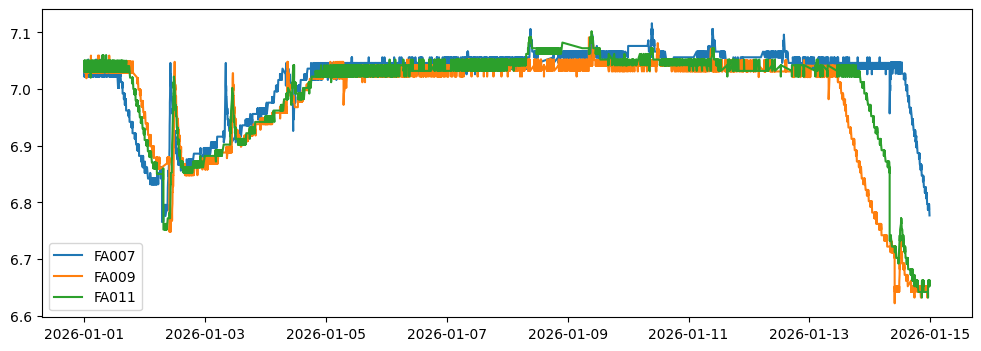

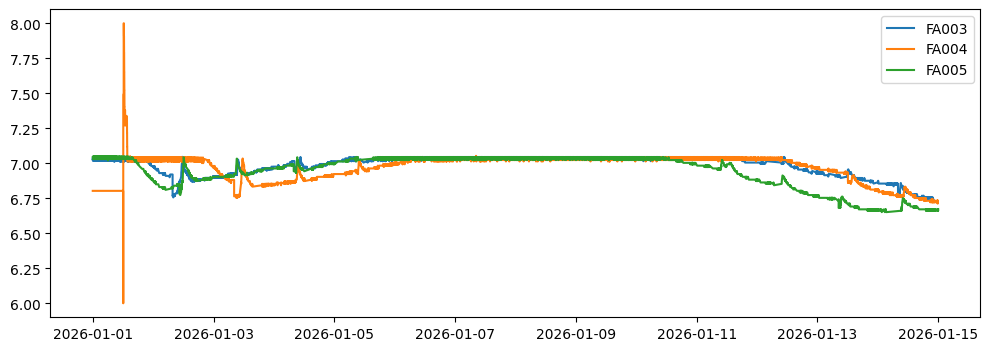

In [49]:
df_analysis = temp_df

plt.figure(figsize = (12, 4))

for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.legend()

In [19]:
ph_df = pd.read_excel("./data/air_data/TI142-temperature.xlsx")
ph_df.insert(0, "Batch", ph_df["start"].apply(lambda x: mapping[x]))
ph_df

BadZipFile: File is not a zip file

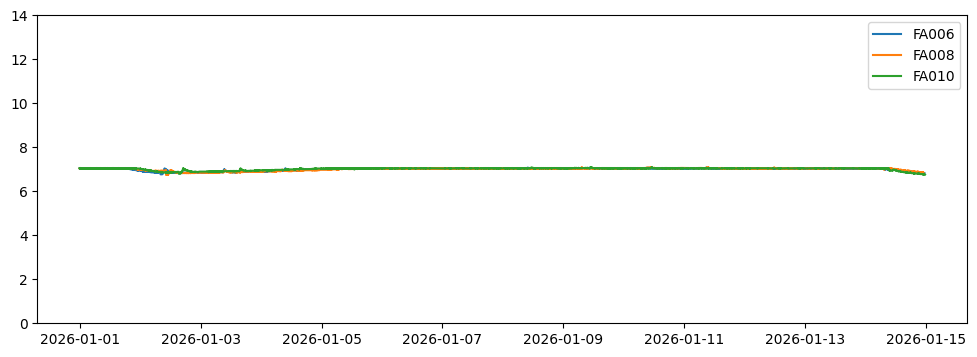

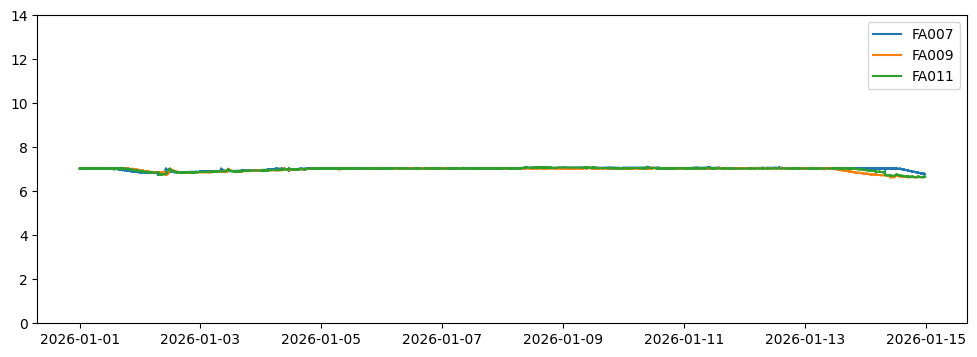

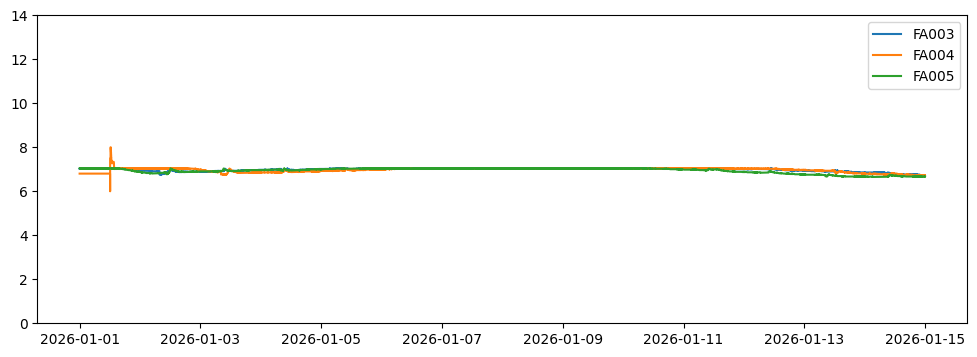

In [20]:
df_analysis = ph_df

plt.figure(figsize = (12, 4))
for batch in ["FA006", "FA008", "FA010"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.ylim(0, 14)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA007", "FA009", "FA011"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.ylim(0, 14)
plt.legend()

plt.figure(figsize = (12, 4))
for batch in ["FA003", "FA004", "FA005"]:
    sub_df = df_analysis[df_analysis["Batch"] == batch].copy()
    sub_df = sub_df[sub_df["value"].astype(float) >= 0]
    sub_df["timestamp"] = pd.to_datetime(sub_df["timestamp"])
    sub_df = sub_df[sub_df["timestamp"] >= batch_start[batch]]
    sub_df = sub_df[sub_df["timestamp"] <= batch_start[batch] + pd.Timedelta(days = 14)]
    sub_df["timestamp"] = pd.to_datetime("01-01-2026 00:00:00") + (sub_df["timestamp"] - sub_df["timestamp"].min())
    plt.plot(sub_df["timestamp"], sub_df["value"], label = batch)
plt.ylim(0, 14)
plt.legend()